# Superstore Sales Analysis

## Project Overview
This project analyzes sales data from a Superstore to uncover insights about sales performance, profitability, regional differences, and the impact of discounts.

Key Analyses included:
- Sales and Profit by Region
- Sales and Profit by Category
- Monthly Sales Trend
- Top Loss-Making Products
- Sales by Customer Segment
- Relationship between Discount and Profit
- Top Sub-Categories by Sales and Profit

## 1. Data Loading and Cleaning

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
df = pd.read_csv("superstore.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


In [4]:
df.shape

(10800, 21)

In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10800 non-null  object 
 1   Order ID       10800 non-null  object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quanti

In [7]:
df.isnull().sum()

Row ID             0
Order ID           0
Order Date       806
Ship Date        806
Ship Mode        806
Customer ID      806
Customer Name    806
Segment          806
Country          806
City             806
State            806
Postal Code      817
Region           806
Product ID       806
Category         806
Sub-Category     806
Product Name     806
Sales            806
Quantity         806
Discount         806
Profit           806
dtype: int64

In [8]:
df = df.dropna(how='all')
df.shape

(10800, 21)

In [9]:
df = df.dropna(subset=['Order Date', 'Sales', 'Profit'])
df.shape

(9994, 21)

In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Discount'] = pd.to_numeric(df['Discount'], errors='coerce')

print("Data types updated successfully")

Data types updated successfully


In [28]:
df.describe()

,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994,9994,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,2017-04-30 05:17:08.056834048,2017-05-04 04:17:20.304182528,55245.233297,229.858001,3.789574,0.156203,28.656896
min,2015-01-03 00:00:00,2015-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2016-05-23 00:00:00,2016-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,2017-06-26 00:00:00,2017-06-29 00:00:00,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,2018-05-14 00:00:00,2018-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,2018-12-30 00:00:00,2019-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,NaN,NaN,32038.715955,623.245101,2.225110,0.206452,234.260108


## 2. Sales by Region

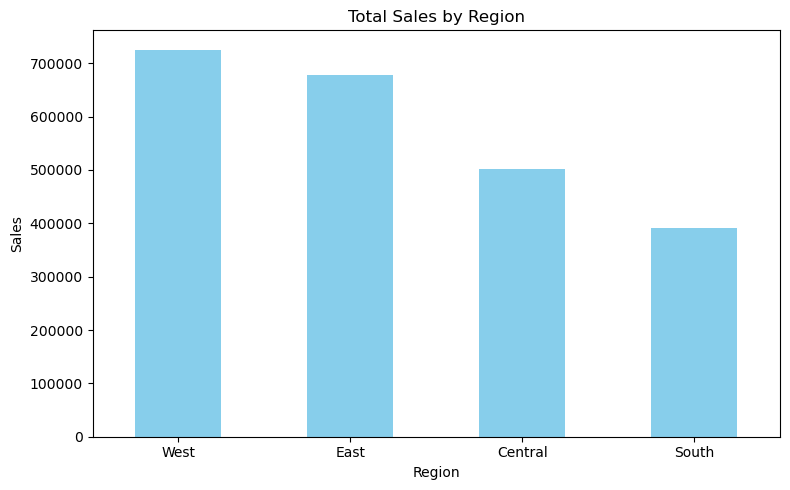

In [13]:
plt.figure(figsize=(8,5))
sales_by_region.plot(kind='bar', color='skyblue')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Sales by Category

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


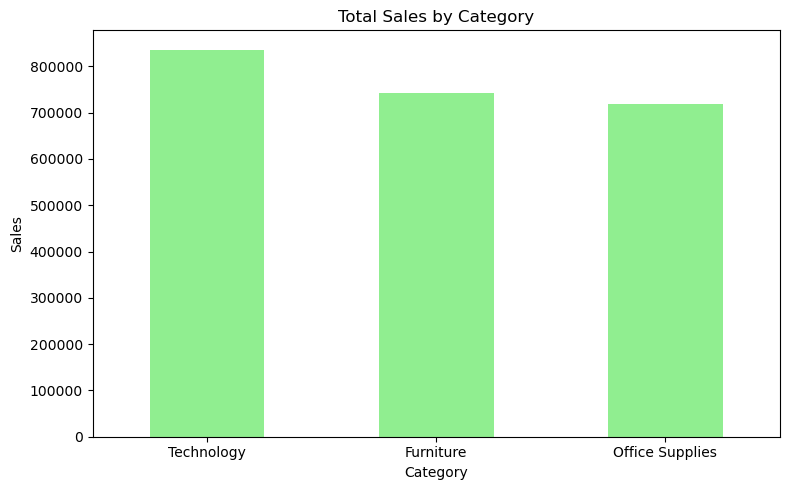

In [14]:
sales_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(sales_by_category)

plt.figure(figsize=(8,5))
sales_by_category.plot(kind='bar', color='lightgreen')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


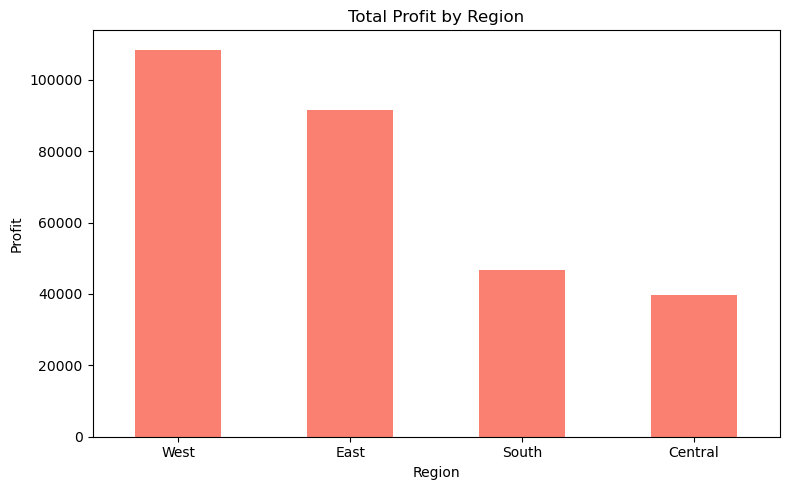

In [15]:
profit_by_region = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
print(profit_by_region)

plt.figure(figsize=(8,5))
profit_by_region.plot(kind='bar', color='salmon')
plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Profit')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Monthly Sales Trend

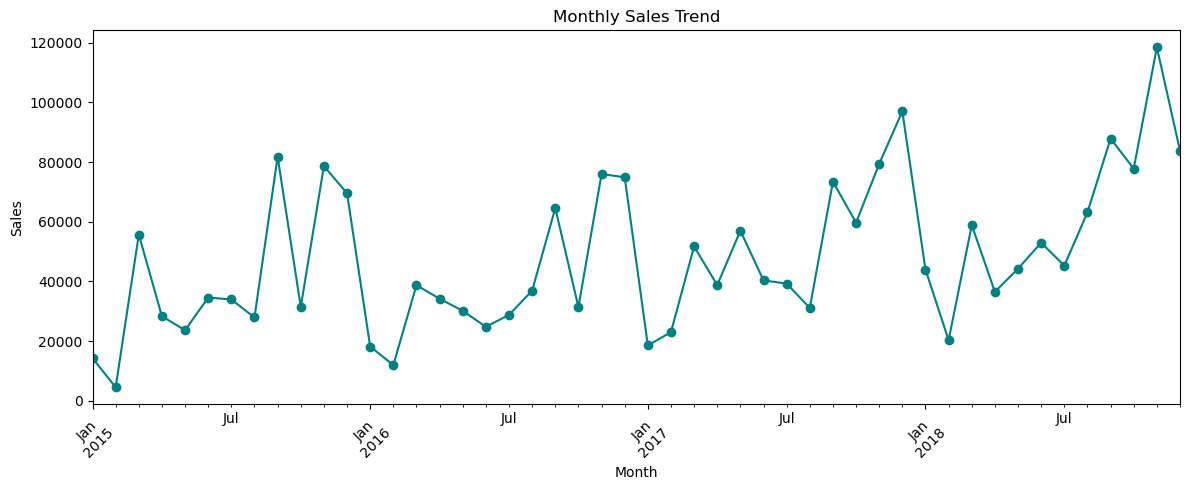

In [16]:
df['Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot(kind='line', marker='o', color='teal')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Profit Analysis

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


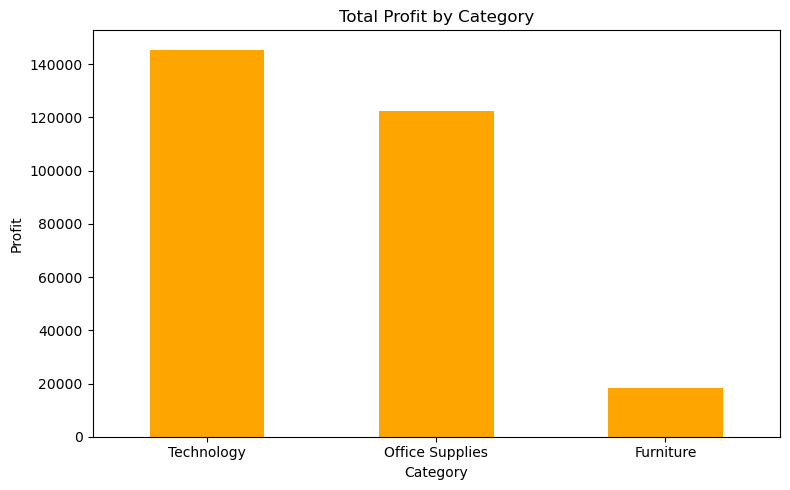

In [17]:
profit_by_category = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print(profit_by_category)

plt.figure(figsize=(8,5))
profit_by_category.plot(kind='bar', color='orange')
plt.title('Total Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Top Loss-Making Products

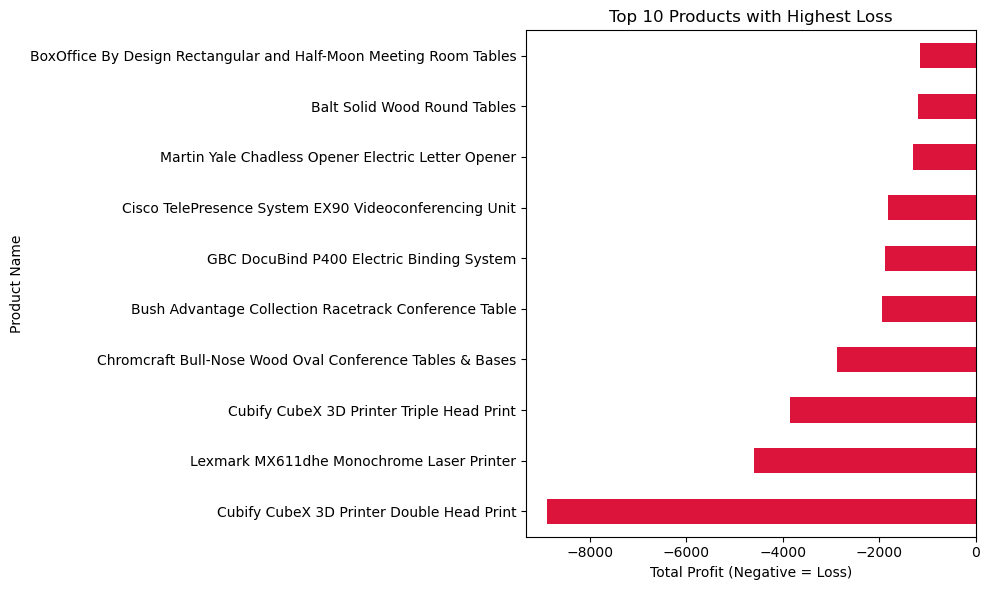

In [19]:
loss_products = df.groupby('Product Name')['Profit'].sum().sort_values().head(10)
loss_products = loss_products.sort_values(ascending=True) 

plt.figure(figsize=(10,6))
loss_products.plot(kind='barh', color='crimson')
plt.title('Top 10 Products with Highest Loss')
plt.xlabel('Total Profit (Negative = Loss)')
plt.tight_layout()
plt.show()

## 7. Sales by Customer Segment

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64


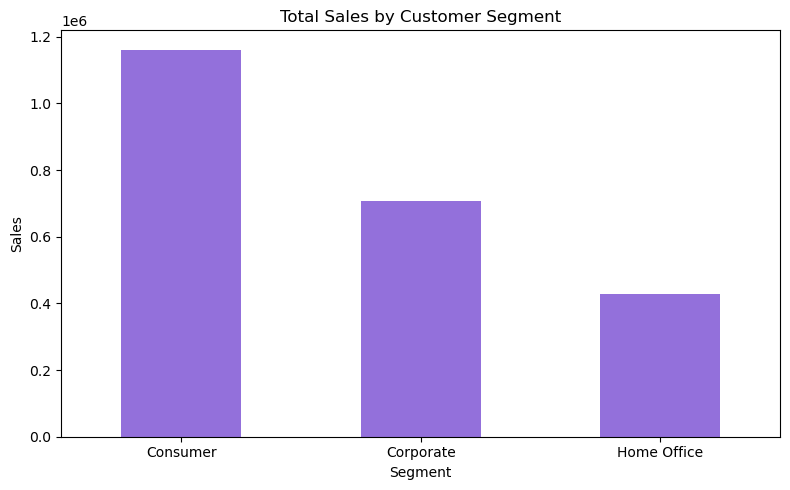

In [20]:
sales_by_segment = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
print(sales_by_segment)

plt.figure(figsize=(8,5))
sales_by_segment.plot(kind='bar', color='mediumpurple')
plt.title('Total Sales by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Discount vs Profit

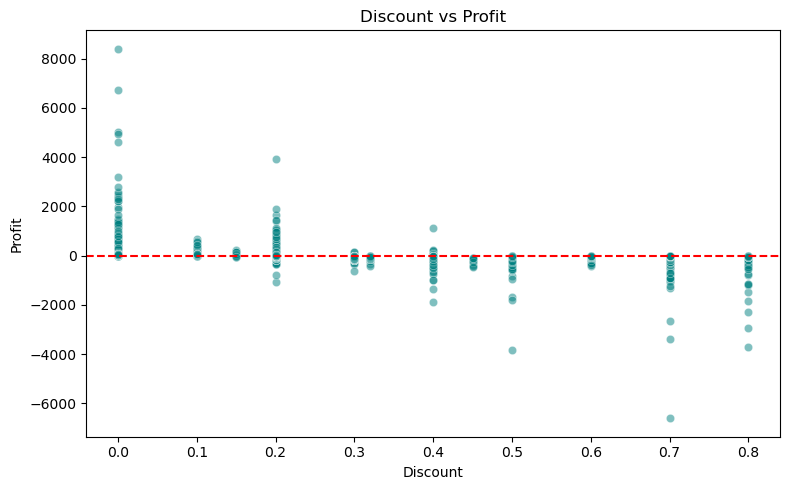

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.5, color='teal')
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.axhline(0, color='red', linestyle='--')  # خط صفر برای نشون دادن ضرر
plt.tight_layout()
plt.show()

## 9. Sub-Category Analysis

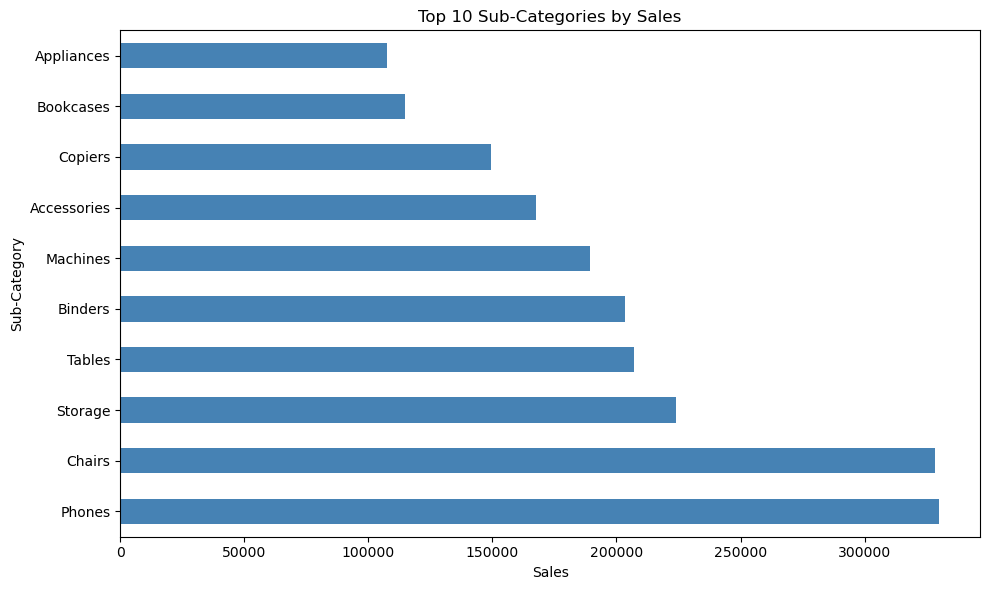

In [22]:
sales_by_subcategory = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sales_by_subcategory.plot(kind='barh', color='steelblue')
plt.title('Top 10 Sub-Categories by Sales')
plt.xlabel('Sales')
plt.tight_layout()
plt.show()

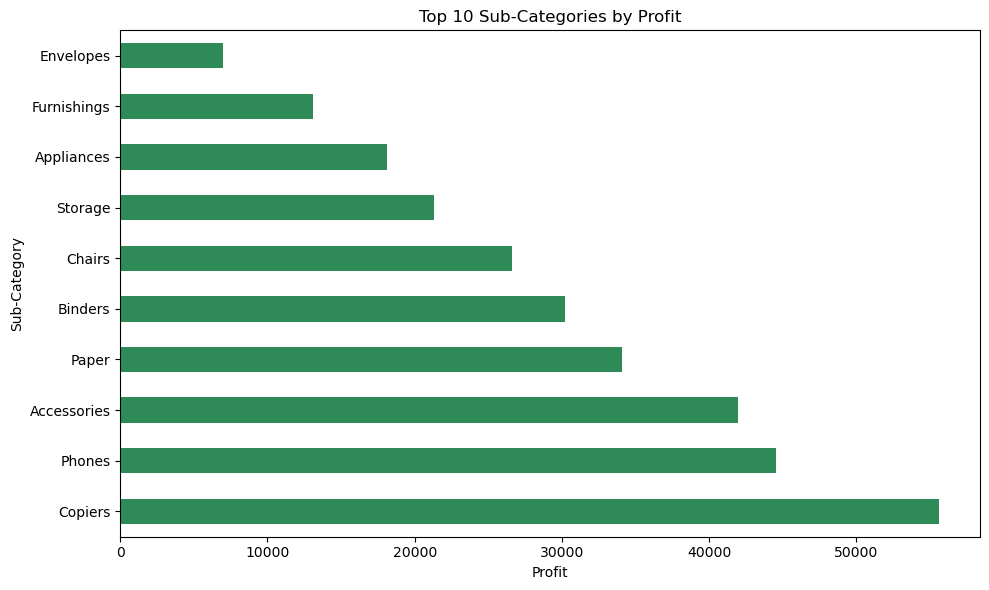

In [23]:
profit_by_subcategory = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
profit_by_subcategory.plot(kind='barh', color='seagreen')
plt.title('Top 10 Sub-Categories by Profit')
plt.xlabel('Profit')
plt.tight_layout()
plt.show()

## 10. Key Insights & Conclusions

- The West region has the highest sales, while the South has the lowest.
- Technology is the top-performing category in both sales and profit.
- High discounts (especially above 0.3) often lead to losses.
- Some products, particularly certain printers and tables, generate significant losses and need review.
- Consumer segment contributes the most to total sales.
- Monthly sales show seasonal patterns that can help with inventory planning.

### Recommendations:
- Reduce heavy discounts on low-margin products.
- Focus marketing efforts on Technology products and the West region.
- Investigate and possibly discontinue the top loss-making products.